Initial steps to understanding this topic

In [35]:
# importing libraries
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
np.random.normal(5, 2)



5.406412864586132

### Building the OU process - 2023 paper

$$ d X_t dt = - X_t dt + \sqrt{2} dB_t , \quad X_0 \sim \pi_D $$

This is the same as the following:
$X_t = m_t X_0 + \sigma_t Z_t$ where $ m_t = e^{-t}$ and $\sigma_t^2 = 1- e^{-2t}$.

$$X_t \rightarrow \mathcal{N}(0,I)$$
 

## Building most basic python setup. 
- Forward process, need to be able to sample from $X_t|X_0$. Use this to generate training data for the score estimator. 
Choose $d=2$ and need to choose T.
- SGDL optimisation. Define the loss function score matching objective rewritten via denoising score matching $$U(\theta) = \mathbb{E}[\kappa (\tau) | \sigma_\tau^{-1}Z + s(\tau, \theta, m_\tau X_0 + \sigma_\tau Z)|^2] + C$$
Use the SGLD algo
$$ \theta_0^\lambda := \theta_0, \quad \theta_{n+1}^\lambda = \theta_n^\lambda - \lambda H(\theta_n^\lambda, \mathbf{X}_{n+1}) + \sqrt{2\lambda/\beta} \, \xi_{n+1}, \quad n \in \mathbb{N}_0$$

In [33]:
# Generating samples from the 'unknown mean - known sigma' distribuition we want to estimate the score.
# We want to be able to understand pi_D

np.random.seed(1)

d = 2           #set the dimension as 2 for now
sigma2_known = 1

mu_unknown = np.random.uniform(0, 1, d)
print(f'mu of the data we want to understand = {mu_unknown}')

# sample of Data we are trying to understand.
X_0 = np.random.normal(mu_unknown, sigma2_known, d)



# gamma = 0.01    # time step, ie delta t
t_0 = 0         # initial time
T = 1           # final time

# numsteps = (T - t_0)/gamma
numsteps = 100

t = np.linspace(t_0, T, numsteps)


# Generating gaussian noise to perturb the data with
Z = []
m = np.exp(-t)              # mu calculation solved from the solution to the ODE
sigma2 = 1 - np.exp(-2*t) #variance calculation
X= []

# loop over all time indices
for i in range(len(t)):
    # generate the standard normal noise of dimension d matching the data
    Z_t = np.random.normal(0, 1, d)
    Z.append(Z_t)


    X_t = m[i] * X_0 + np.sqrt(sigma2[i]) * Z_t
    X.append(X_t)



print(f'X_0  = {X_0}')


mu of the data we want to understand = [0.417022   0.72032449]
X_0  = [-0.11114975 -0.35264413]


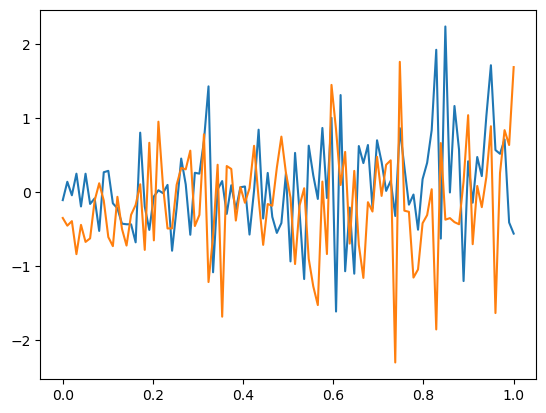

In [37]:
plt.plot(t, X)